# Импорты

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Задание 1

## Входные данный

In [2]:
X = np.array([
    10.2,
    9.23,
    8.77,
    10.4,
    9.44,
    9.09,
    6.30,
    9.42,
    6.12,
    9.69,
    8.59,
    8.68,
    7.97,

    8.64,
    6.45,
    5.29,
    5.00,
    8.42,
    8.84,
    8.26,
    6.66,
    6.96,
    6.51,
    6.72,
    6.00,
    5.36
])

## Гистограмма

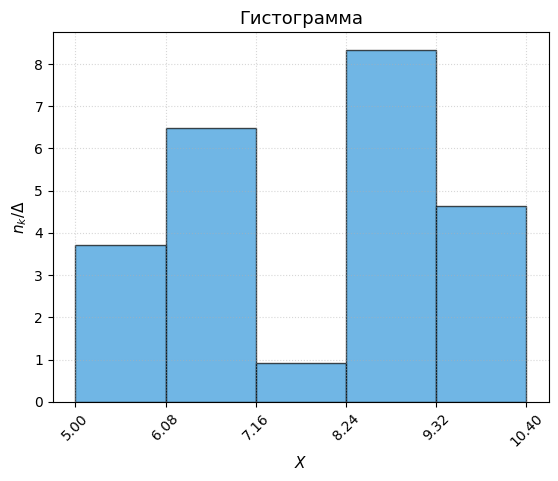

In [15]:
X_min = min(X)
X_max = max(X)
R = X_max - X_min
N = int(1 + 3.322 * np.log10(len(X)))
delta = R / N

bins = [X_min + i * delta for i in range(N + 1)]
bins[-1] = X_max

counts, _ = np.histogram(X, bins=bins)
heights = counts / delta

plt.bar(
    bins[:-1],
    heights,
    width=delta,
    align="edge",
    color="#3498db",
    edgecolor="black",
    alpha=0.7,
    label=r"$n_k / \Delta$",
)

plt.title("Гистограмма", fontsize=13)
plt.xlabel("$X$", fontsize=11)
plt.ylabel(r"$n_k / \Delta$", fontsize=11)

plt.xticks(bins, labels=[f"{b:.2f}" for b in bins], rotation=45)

plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

## Полигон

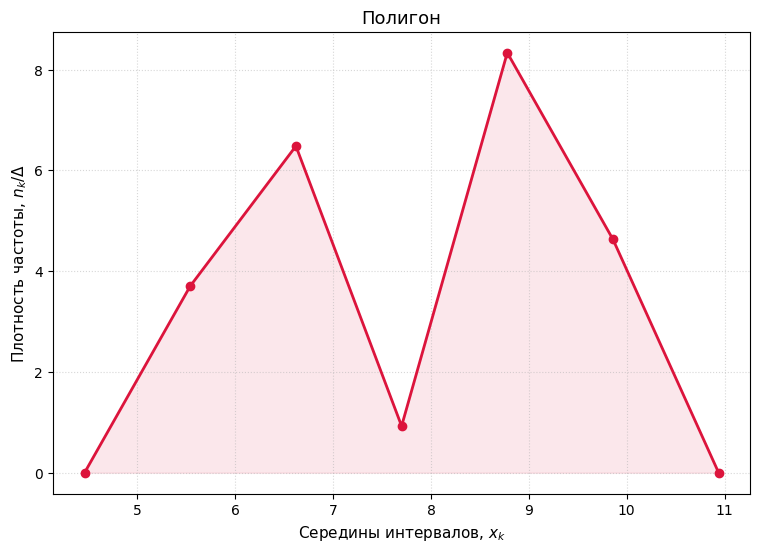

In [16]:
bin_centers = [bins[i] + delta / 2 for i in range(len(bins) - 1)]

centers_extended = [bin_centers[0] - delta] + list(bin_centers)
heights_extended = [0.0] + list(heights)

centers_extended.append(bin_centers[-1] + delta)
heights_extended.append(0.0)

plt.figure(figsize=(9, 6))

plt.plot(
    centers_extended,
    heights_extended,
    color="crimson",
    linestyle="-",
    linewidth=2,
    marker="o",
    markersize=6,
    label="Полигон",
)
plt.fill_between(centers_extended, heights_extended, color="crimson", alpha=0.1)

plt.title("Полигон", fontsize=13)
plt.xlabel("Середины интервалов, $x_k$", fontsize=11)
plt.ylabel(r"Плотность частоты, $n_k / \Delta$", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

## Огива

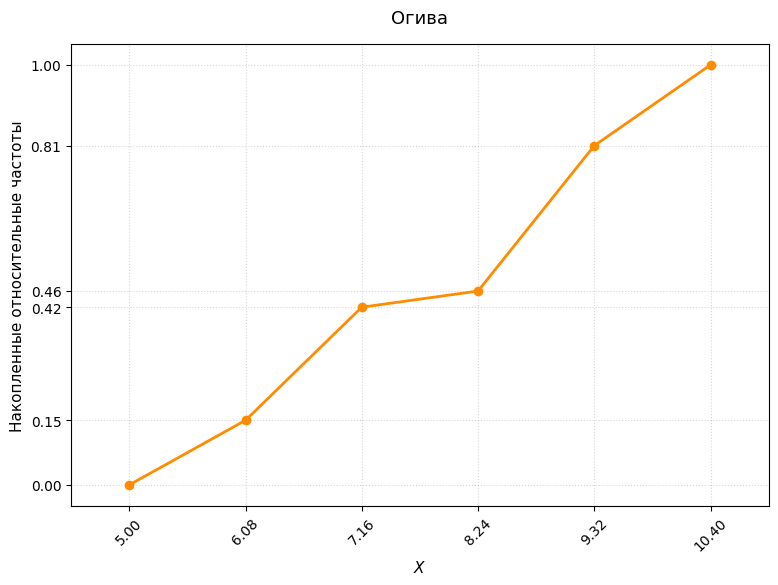

In [ ]:
w_k = counts / len(X)
F_cum = np.insert(np.cumsum(w_k), 0, 0.0)

plt.figure(figsize=(9, 6))

plt.plot(
    bins,
    F_cum,
    color="darkorange",
    linestyle="-",
    linewidth=2,
    marker="o",
    markersize=6,
)

plt.title("Огива", fontsize=13, pad=15)
plt.xlabel("$X$", fontsize=11)
plt.ylabel("Накопленные относительные частоты", fontsize=11)

plt.xticks(bins, labels=[f"{b:.2f}" for b in bins], rotation=45)
plt.yticks(F_cum, labels=[f"{f:.2f}" for f in F_cum])

plt.xlim(min(bins) - delta / 2, max(bins) + delta / 2)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

# Задание 2

## Входные данные

In [21]:
X = [
    2,
    3,
    2,
    1,
    2,
    2,
    4,
    0,
    2,
    4,
    4,
    0,
    1,
    5,
    1,

    1,
    3,
    2,
    2,
    1,
    4,
    2,
    2,
    0,
    1,
    2,
    4,
    2,
    0,
    2
]

## Гистограмма

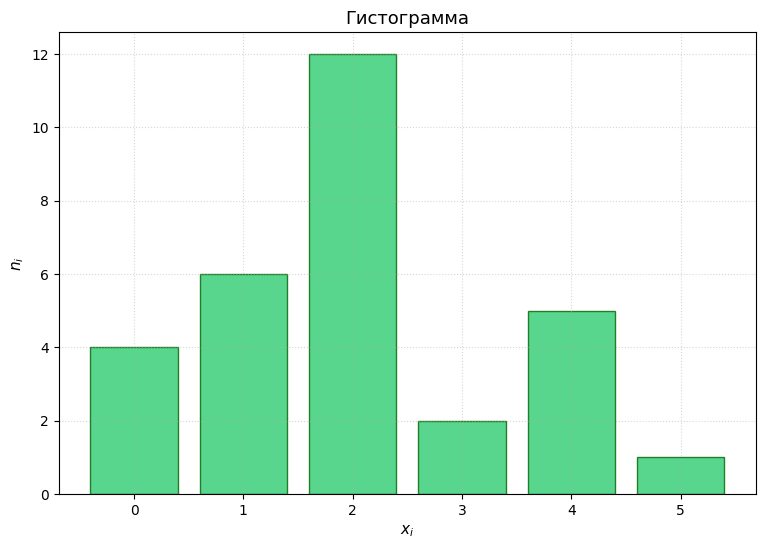

In [23]:
variants, counts = np.unique(X, return_counts=True)

plt.figure(figsize=(9, 6))

plt.bar(
    variants,
    counts,
    color="#2ecc71",
    edgecolor="darkgreen",
    alpha=0.8,
)

plt.title("Гистограмма", fontsize=13)
plt.xlabel("$x_i$", fontsize=11)
plt.ylabel("$n_i$", fontsize=11)

plt.xticks(variants)
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

## Полигон

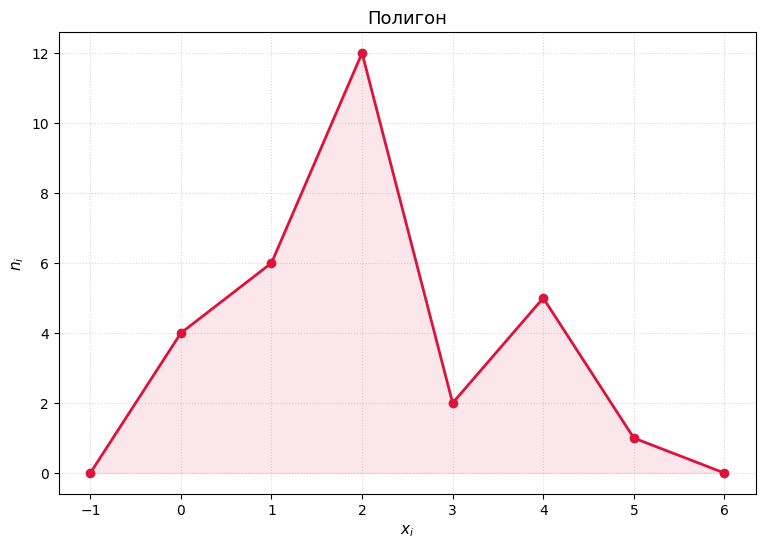

In [24]:
step = np.min(np.diff(variants)) if len(variants) > 1 else 1.0
variants_extended = np.concatenate([[variants[0] - step], variants, [variants[-1] + step]])
counts_extended = np.concatenate([[0.0], counts, [0.0]])

plt.figure(figsize=(9, 6))

plt.plot(
    variants_extended,
    counts_extended,
    color="crimson",
    linestyle="-",
    linewidth=2,
    marker="o",
    markersize=6,
    label="Полигон частот",
)

plt.fill_between(
    variants_extended, counts_extended, color="crimson", alpha=0.1
)

plt.title("Полигон", fontsize=13)
plt.xlabel("$x_i$", fontsize=11)
plt.ylabel("$n_i$", fontsize=11)

plt.xticks(variants_extended)
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

## Огива

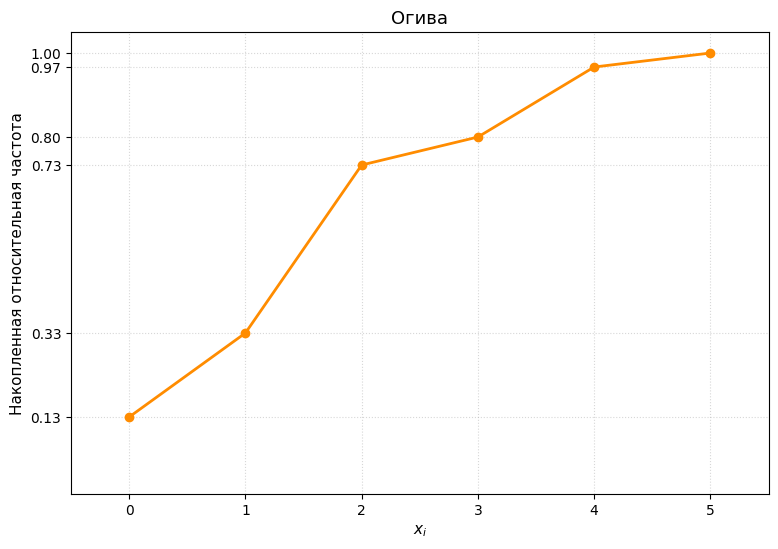

In [25]:
w_i = counts / len(X)
F_cum = np.cumsum(w_i)

plt.figure(figsize=(9, 6))

plt.plot(
    variants,
    F_cum,
    color="darkorange",
    linestyle="-",
    linewidth=2,
    marker="o",
    markersize=6,
    label="Огива частот",
)

plt.title("Огива", fontsize=13)
plt.xlabel("$x_i$", fontsize=11)
plt.ylabel("Накопленная относительная частота", fontsize=11)

plt.xticks(variants, labels=[f"{v}" for v in variants])
plt.yticks(F_cum, labels=[f"{f:.2f}" for f in F_cum])

plt.xlim(min(variants) - 0.5, max(variants) + 0.5)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.5)

plt.show()